# 03 — Communication Sentiment Analysis (VADER & RoBERTa)

This notebook compares two sentiment analyzers applied to the internal agent-to-agent messages of the 70 experiment runs. VADER is a lexicon/rule-based tool trained on social-media English; it tends to score formal, task-focused agent messages as neutral or strongly positive. The fine-tuned Transformer model, `cardiffnlp/twitter-roberta-base-sentiment-latest`, reads whole-sentence context and better captures LLM-specific tone, such as the positive bias introduced by RLHF. Because RoBERTa has a 512-token context window, long messages are split into 510-token chunks, every chunk is scored, and the probabilities are length-weighted averaged into one score per message. VADER results are shown in blue and RoBERTa results are purple throughout the notebook.

## §0 — Method and Data Loading

This section imports the required libraries and loads the pre-computed `sentiment_vader.json` and `sentiment_roberta.json` artifacts of the 70 experiment runs. It builds message-level and run-level DataFrames for each analyzer and exports all four DataFrames to `sentiment_data.xlsx`. VADER is represented in blue, RoBERTa in purple, and the shared plotting utilities render short tasks as 50% transparent bars and long tasks as opaque bars.

In [1]:
import json
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba, to_hex
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
from pathlib import Path
from matplotlib.lines import Line2D

# Shared loader for the sentiment artifacts.
sys.path.insert(0, os.path.abspath('..'))
from src.analysis.sentiment_io import find_run_dirs, load_sentiment, load_analyzer_meta

ANALYZERS = ['vader', 'roberta']
ANALYZER_COLORS = {'vader': '#1f77b4', 'roberta': '#9467bd'}   # blue, purple

# Set visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14

STYLE_COLORS = {
    'coercive': '#e41a1c',
    'authoritative': '#ff7f0e',
    'affiliative': '#ff80c5',
    'democratic': '#377eb8',
    'pacesetting': '#984ea3',
    'coaching': '#4daf4a',
    'baseline': '#7f7f7f'
}

STYLE_ORDER = ['coercive', 'authoritative', 'affiliative', 'democratic', 'pacesetting', 'coaching', 'baseline']

AGENT_COLORS = {
    'Boss': '#FF3366',
    'Coder': '#00D4FF',
    'Writer': '#0066FF',
    'Reviewer': '#7B2CBF',
    'Team Mean': '#00E5A3'
}

BOSS_WORKER_COLORS = {
    'Boss': '#FF3366',
    'Worker': '#00E5A3',
    'Workers': '#00E5A3'
}

# Recolor bars/boxes so short = 50% transparent, long = opaque
def color_style_task_bars(ax, edgecolor='white'):
    for j, container in enumerate(ax.containers):
        task = ['short', 'long'][j]
        alpha = 0.5 if task == 'short' else 1.0
        for i, artist in enumerate(container):
            style = STYLE_ORDER[i]
            patch = artist.box if hasattr(artist, 'box') else artist
            patch.set_facecolor(to_rgba(STYLE_COLORS[style], alpha=alpha))
            if edgecolor:
                patch.set_edgecolor(edgecolor)


def add_short_long_legend(ax=None, fig=None, sample_color='#555555', title='Task type', loc='upper right', **kwargs):
    """Add a legend that explains short = 50% transparent, long = opaque."""
    handles = [
        Patch(facecolor=to_rgba(sample_color, 0.5), edgecolor='black', label='Short task'),
        Patch(facecolor=to_rgba(sample_color, 1.0), edgecolor='black', label='Long task')
    ]
    if fig is not None:
        return fig.legend(handles=handles, title=title, loc=loc, frameon=False, **kwargs)
    return ax.legend(handles=handles, title=title, loc=loc, frameon=False, **kwargs)


# Load the pre-computed sentiment artifacts
RESULTS_DIR = os.path.abspath(os.path.join('..', 'results'))
run_dirs = [str(d) for d in find_run_dirs(RESULTS_DIR)]

SENTIMENT = {}
for a in ANALYZERS:
    df_msg, df_run = load_sentiment(RESULTS_DIR, analyzer=a, style_order=STYLE_ORDER)
    SENTIMENT[a] = (df_msg, df_run)

# Print provenance for both analyzers
for a in ANALYZERS:
    meta = load_analyzer_meta(RESULTS_DIR, a)
    print(f'--- {a.upper()} ---')
    print(f"  Analyzer: {meta.get('name')} ({meta.get('kind')}) -- {meta.get('model')}")
    if meta.get('revision'):
        print(f"  revision: {meta['revision']}")
    if meta.get('chunking'):
        print(f"  chunking: {meta['chunking']}")
    print(f"  compound: {meta.get('compound_definition')}  |  versions: {meta.get('versions')}")
    print(f'  Loaded {len(SENTIMENT[a][0])} messages from {len(SENTIMENT[a][1])} runs')
print()
print(SENTIMENT['vader'][1].head())

# Excel export of all four DataFrames
with pd.ExcelWriter('sentiment_data.xlsx', engine='openpyxl') as writer:
    for a in ANALYZERS:
        df_msg, df_run = SENTIMENT[a]
        df_msg.to_excel(writer, sheet_name=f'{a}_messages', index=False)
        df_run.to_excel(writer, sheet_name=f'{a}_runs', index=False)
print('Exported sentiment_data.xlsx with sheets: vader_messages, vader_runs, roberta_messages, roberta_runs')

# Figure export
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)


def save_fig(name, dpi=200):
    plt.gcf().savefig(FIG_DIR / f'{name}.png', dpi=dpi, bbox_inches='tight', facecolor='white')

--- VADER ---
  Analyzer: vader (lexicon) -- vaderSentiment.SentimentIntensityAnalyzer
  compound: vader_compound  |  versions: {'vaderSentiment': '3.3.2'}
  Loaded 1033 messages from 70 runs
--- ROBERTA ---
  Analyzer: roberta (transformer) -- cardiffnlp/twitter-roberta-base-sentiment-latest
  revision: 3216a57f2a0d9c45a2e6c20157c20c49fb4bf9c7
  chunking: {'max_tokens': 512, 'chunk_tokens': 510, 'pooling': 'length_weighted_mean'}
  compound: positive_minus_negative  |  versions: {'transformers': '4.57.6', 'torch': '2.13.0'}
  Loaded 1033 messages from 70 runs

         style  task run_id                 run_dir  run_mean_compound  \
0  affiliative  long     01  affiliative_long_run01             0.9703   
1  affiliative  long     02  affiliative_long_run02             0.9779   
2  affiliative  long     03  affiliative_long_run03             0.9601   
3  affiliative  long     04  affiliative_long_run04             0.9656   
4  affiliative  long     05  affiliative_long_run05           

## §1 — Overall Communication Sentiment by Leadership Style

Two barplots show the mean run-level compound score for each leadership style, split by short and long tasks, with VADER in the upper panel and RoBERTa in the lower panel. The x-axis lists the seven leadership styles, the y-axis is the compound score from -1 to +1, and short tasks are drawn as 50% transparent bars while long tasks are fully opaque. Error bars show ±1 standard error. VADER compresses scores toward the positive end, whereas RoBERTa produces a wider spread across styles.

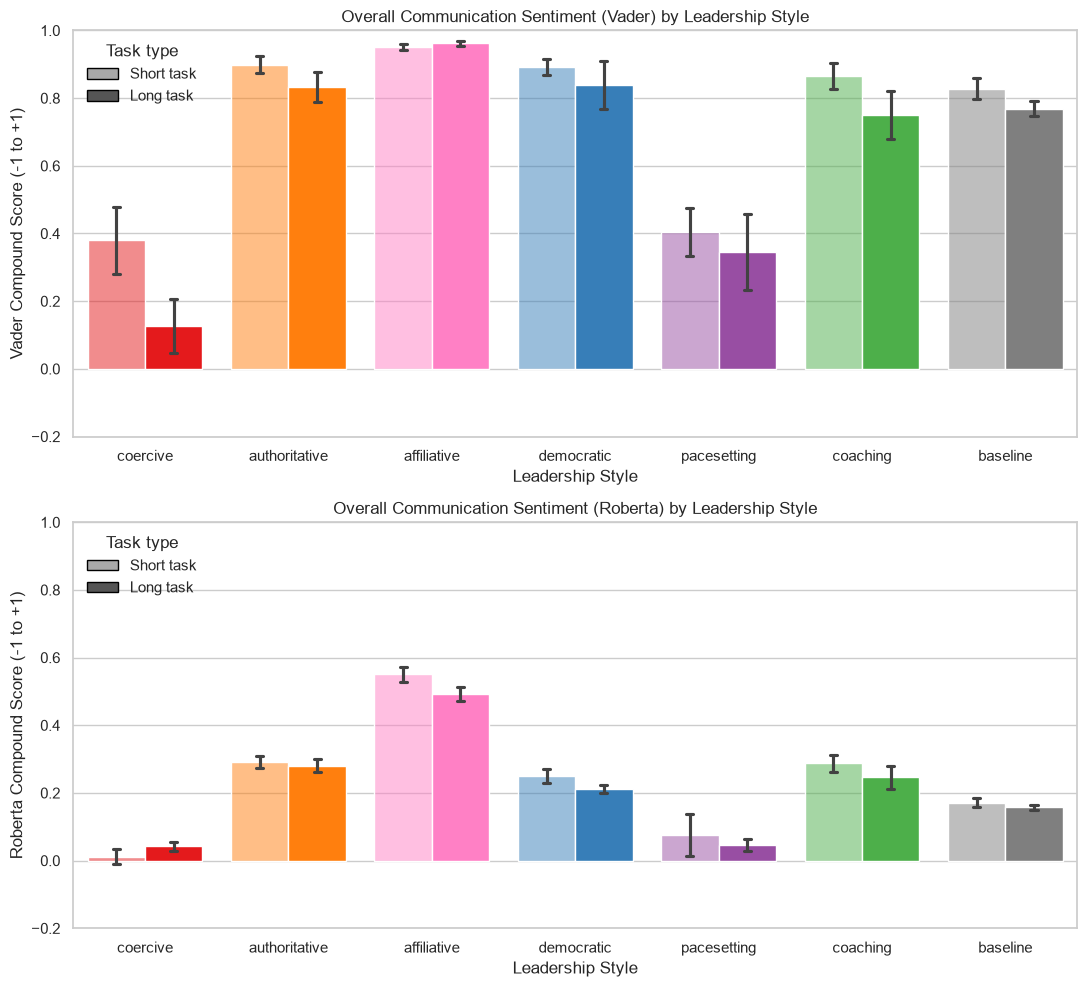

--- VADER ---
Run-level mean compound sentiment by leadership style (vader):
                 mean     std     min     max
style                                        
coercive       0.2530  0.2331 -0.0842  0.5871
authoritative  0.8653  0.0838  0.6925  0.9633
affiliative    0.9563  0.0176  0.9288  0.9779
democratic     0.8650  0.1154  0.5621  0.9564
pacesetting    0.3750  0.2025 -0.0460  0.6112
coaching       0.8076  0.1346  0.5268  0.9773
baseline       0.7977  0.0649  0.7051  0.9306

--- ROBERTA ---
Run-level mean compound sentiment by leadership style (roberta):
                 mean     std     min     max
style                                        
coercive       0.0263  0.0420 -0.0400  0.0879
authoritative  0.2856  0.0407  0.2272  0.3541
affiliative    0.5220  0.0541  0.4547  0.6050
democratic     0.2304  0.0411  0.1839  0.2992
pacesetting    0.0615  0.0976 -0.0552  0.2500
coaching       0.2666  0.0656  0.1289  0.3760
baseline       0.1642  0.0238  0.1392  0.2173



In [2]:
fig, axes = plt.subplots(2, 1, figsize=(11, 10))

for i, analyzer in enumerate(ANALYZERS):
    df_msg, df_run = SENTIMENT[analyzer]
    sns.barplot(
        data=df_run, x='style', y='run_mean_compound', hue='task',
        order=STYLE_ORDER, errorbar='se', capsize=0.1, ax=axes[i],
        legend=False, hue_order=['short', 'long']
    )
    color_style_task_bars(axes[i])
    axes[i].set_title(f'Overall Communication Sentiment ({analyzer.title()}) by Leadership Style')
    axes[i].set_ylabel(f'{analyzer.title()} Compound Score (-1 to +1)')
    axes[i].set_xlabel('Leadership Style')
    axes[i].set_ylim(-0.2, 1.0)
    add_short_long_legend(ax=axes[i], loc='upper left')

plt.tight_layout()
save_fig('03_sentiment_by_style')
plt.show()

# Distribution summary tables
for analyzer in ANALYZERS:
    df_msg, df_run = SENTIMENT[analyzer]
    summary = df_run.groupby('style')['run_mean_compound'].agg(['mean', 'std', 'min', 'max']).reindex(STYLE_ORDER)
    print(f'--- {analyzer.upper()} ---')
    print(f'Run-level mean compound sentiment by leadership style ({analyzer}):')
    print(summary.round(4).to_string())
    print()

## §2 — Task Complexity × Leadership Style Interaction

A point plot shows the mean run-level compound score for each leadership style, split by analyzer and task. VADER appears in blue and RoBERTa in purple; long tasks use solid circles and continuous lines, while short tasks use semi-transparent X markers and dashed lines. The y-axis is the compound score from -1 to +1, and the legend identifies the four analyzer × task conditions. Non-parallel lines indicate a style × task interaction, with some leadership styles buffering or amplifying the emotional load of the longer task.

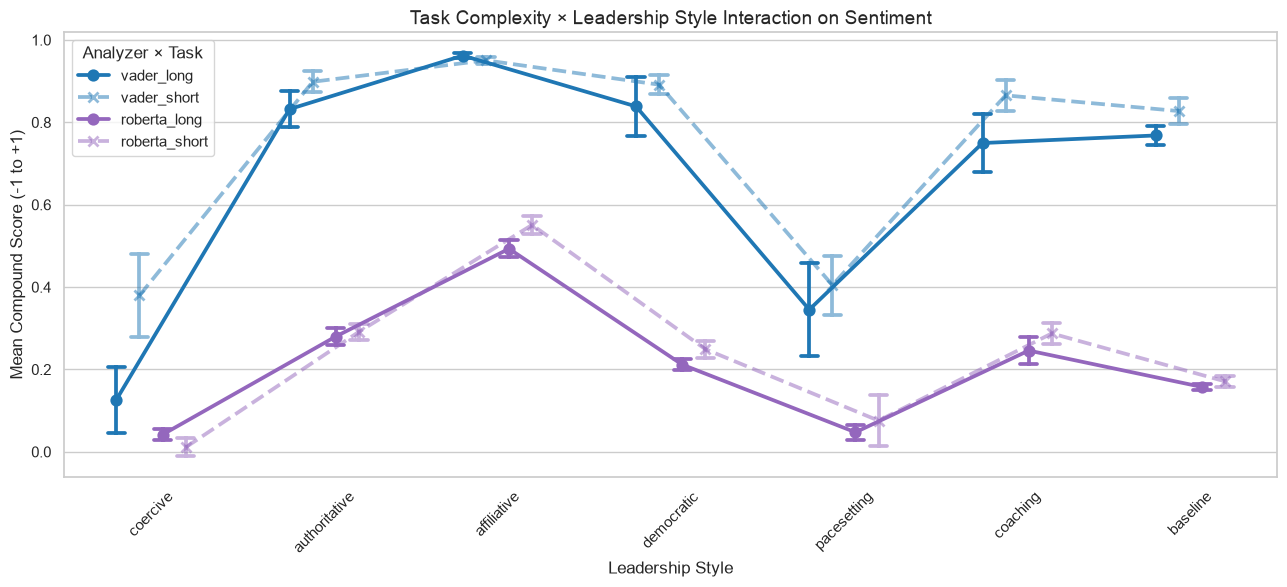

--- VADER ---
Mean run compound sentiment by style and task (vader):
                 mean             std         count      
task             long   short    long   short  long short
style                                                    
coercive       0.1265  0.3796  0.1790  0.2240     5     5
authoritative  0.8321  0.8985  0.0995  0.0562     5     5
affiliative    0.9621  0.9505  0.0158  0.0190     5     5
democratic     0.8386  0.8914  0.1594  0.0529     5     5
pacesetting    0.3451  0.4048  0.2537  0.1602     5     5
coaching       0.7497  0.8655  0.1598  0.0829     5     5
baseline       0.7681  0.8274  0.0494  0.0695     5     5

--- ROBERTA ---
Mean run compound sentiment by style and task (roberta):
                 mean             std         count      
task             long   short    long   short  long short
style                                                    
coercive       0.0417  0.0108  0.0308  0.0493     5     5
authoritative  0.2800  0.2913  0.0436  0.0418

In [3]:
# Concatenate run-level data for both analyzers and tasks
df_list = []
for analyzer in ANALYZERS:
    df_msg, df_run = SENTIMENT[analyzer]
    df_run = df_run.copy()
    df_run['condition'] = f'{analyzer}_' + df_run['task'].astype(str)
    df_list.append(df_run)
df_combined = pd.concat(df_list, ignore_index=True)

condition_order = ['vader_long', 'vader_short', 'roberta_long', 'roberta_short']
df_combined['condition'] = pd.Categorical(df_combined['condition'], categories=condition_order, ordered=True)

c_vader = ANALYZER_COLORS['vader']
c_roberta = ANALYZER_COLORS['roberta']
condition_palette = {
    'vader_long': to_rgba(c_vader, 1.0),
    'vader_short': to_rgba(c_vader, 0.5),
    'roberta_long': to_rgba(c_roberta, 1.0),
    'roberta_short': to_rgba(c_roberta, 0.5)
}

fig, ax = plt.subplots(figsize=(13, 6))
sns.pointplot(
    data=df_combined, x='style', y='run_mean_compound', hue='condition',
    order=STYLE_ORDER, hue_order=condition_order, palette=condition_palette,
    markers=['o', 'x', 'o', 'x'], linestyles=['-', '--', '-', '--'],
    errorbar='se', capsize=0.1, dodge=0.4, ax=ax
)

ax.set_ylabel('Mean Compound Score (-1 to +1)')
ax.set_xlabel('Leadership Style')
ax.set_title('Task Complexity × Leadership Style Interaction on Sentiment', fontsize=14)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Analyzer × Task', loc='upper left')

plt.tight_layout()
save_fig('03_sentiment_task_style_interaction')
plt.show()

# Numeric summary: mean, std, and count by style and task for both analyzers
for analyzer in ANALYZERS:
    df_msg, df_run = SENTIMENT[analyzer]
    summary = df_run.groupby(['style', 'task'], observed=True)['run_mean_compound'].agg(['mean', 'std', 'count']).round(4)
    print(f'--- {analyzer.upper()} ---')
    print(f'Mean run compound sentiment by style and task ({analyzer}):')
    print(summary.unstack().reindex(STYLE_ORDER).to_string())
    print()

## §3 — Phase-Level Sentiment Dynamics

Two figures display how mean compound sentiment changes across the six workflow phases (1 Briefing, 2 Planning, 3 Coding, 4 Writing, 5 Review, 6 Revision). The first figure is a side-by-side heatmap, with VADER on the left and RoBERTa on the right, using a red-to-yellow-to-green color scale for compound scores from -0.5 to +1.0. The second figure plots the same data as connected lines with one line per leadership style; VADER and RoBERTa are again left and right, and the shared legend colors each style.

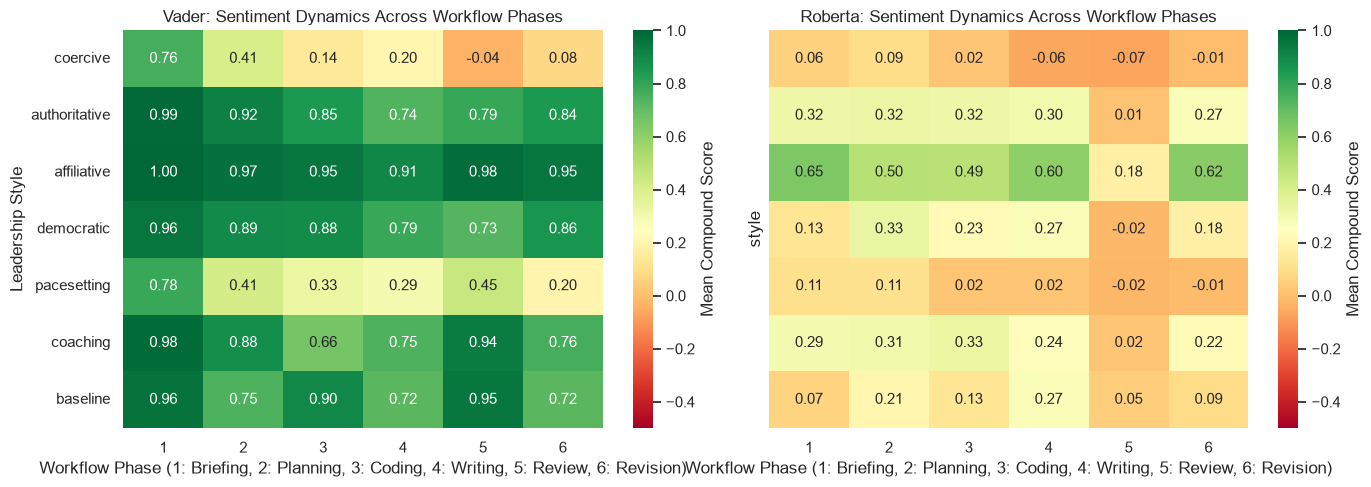

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, analyzer in enumerate(ANALYZERS):
    df_msg, df_run = SENTIMENT[analyzer]
    df_msg_valid = df_msg[df_msg['phase'].notnull()].copy()
    df_msg_valid['phase'] = pd.Categorical(
        df_msg_valid['phase'].astype(int),
        categories=[1, 2, 3, 4, 5, 6],
        ordered=True
    )
    phase_heatmap = df_msg_valid.groupby(['style', 'phase'], observed=True)['compound'].mean().unstack()
    phase_heatmap = phase_heatmap.reindex(STYLE_ORDER)

    sns.heatmap(
        phase_heatmap, annot=True, cmap='RdYlGn', fmt='.2f', vmin=-0.5, vmax=1.0,
        cbar_kws={'label': 'Mean Compound Score'}, ax=axes[i]
    )
    axes[i].set_title(f'{analyzer.title()}: Sentiment Dynamics Across Workflow Phases')
    axes[i].set_xlabel('Workflow Phase (1: Briefing, 2: Planning, 3: Coding, 4: Writing, 5: Review, 6: Revision)')
    if i == 0:
        axes[i].set_ylabel('Leadership Style')

plt.tight_layout()
save_fig('03_sentiment_by_phase')
plt.show()


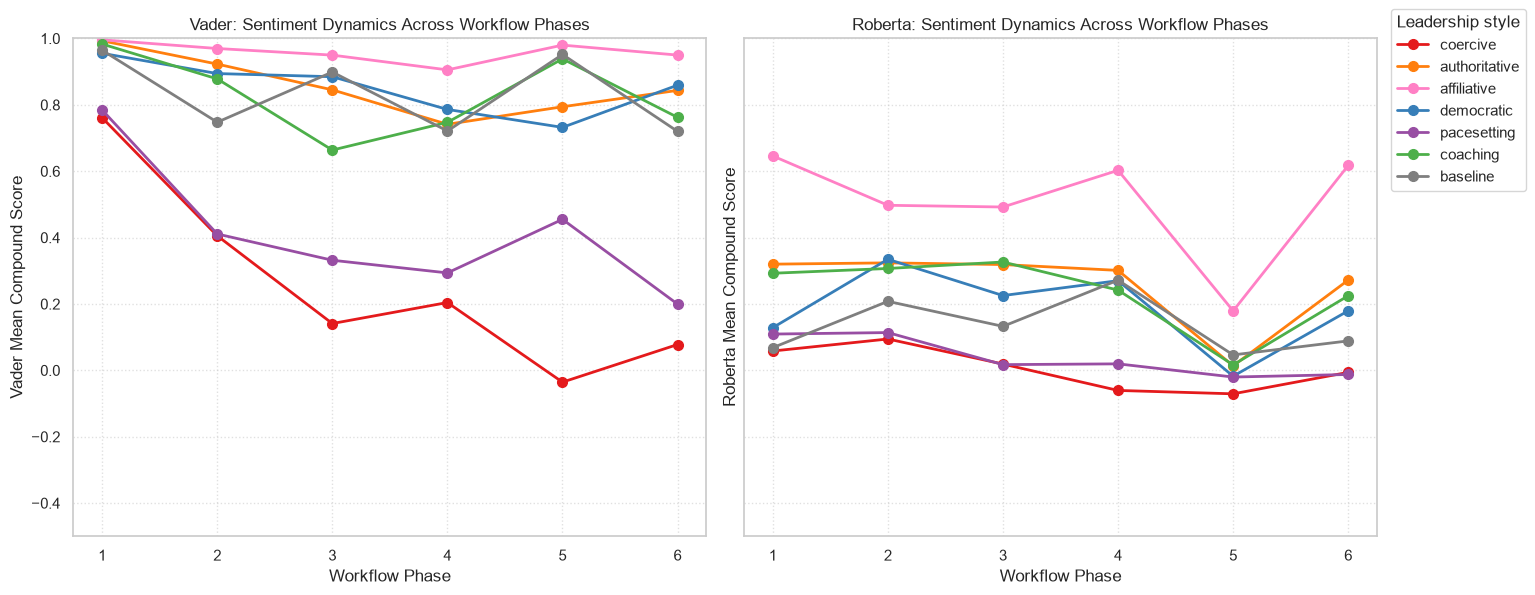

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, analyzer in enumerate(ANALYZERS):
    df_msg, df_run = SENTIMENT[analyzer]
    df_msg_valid = df_msg[df_msg['phase'].notnull()].copy()
    df_msg_valid['phase'] = pd.Categorical(
        df_msg_valid['phase'].astype(int),
        categories=[1, 2, 3, 4, 5, 6],
        ordered=True
    )
    phase_line_means = (df_msg_valid
                        .groupby(['style', 'phase'], observed=True)['compound']
                        .mean()
                        .unstack()
                        .reindex(STYLE_ORDER))
    phase_order = [int(p) for p in df_msg_valid['phase'].cat.categories]

    for style in STYLE_ORDER:
        color = STYLE_COLORS[style]
        axes[i].plot(
            phase_order,
            phase_line_means.loc[style, phase_order].values,
            color=color, marker='o', linewidth=2, markersize=7, label=style
        )

    axes[i].set_xticks(phase_order)
    axes[i].set_xticklabels([str(p) for p in phase_order])
    axes[i].set_ylim(-0.5, 1.0)
    axes[i].set_xlabel('Workflow Phase')
    axes[i].set_ylabel(f'{analyzer.title()} Mean Compound Score')
    axes[i].set_title(f'{analyzer.title()}: Sentiment Dynamics Across Workflow Phases')
    axes[i].grid(True, linestyle=':', alpha=0.6)

# Shared legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Leadership style', loc='upper right', bbox_to_anchor=(1.10, 1))

plt.tight_layout()
save_fig('03_sentiment_by_phase_line')
plt.show()


## §4 — Sentiment Trajectories Over Conversation

This section plots message-level sentiment as the conversation progresses. The first figure is a 7 × 2 grid of cubic regression fits, with leadership styles as rows and VADER on the left and RoBERTa on the right; the x-axis is the message sequence index and the y-axis is the compound score. The second figure bins the conversation into 20 quantile steps and plots the mean compound score for each leadership style. The third figure is another 7 × 2 facet grid showing Boss and worker phase trajectories, with the Boss in pink, workers in green, and shaded bands representing ±1 standard error.

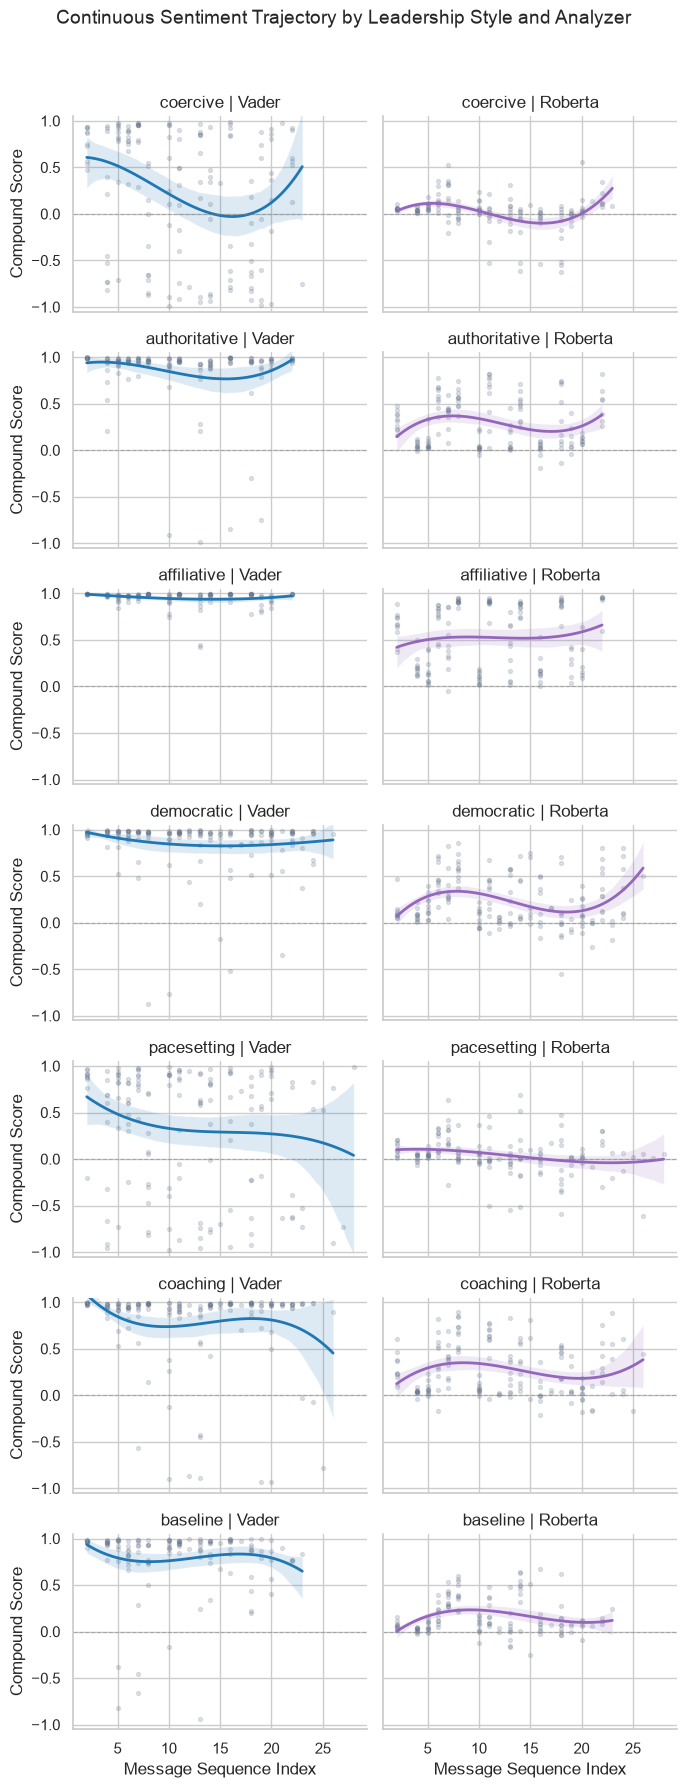

Vader linear sentiment slope (compound per seq) by style:
style
coercive        -0.02811
authoritative   -0.00640
affiliative     -0.00167
democratic      -0.00413
pacesetting     -0.01708
coaching        -0.00804
baseline        -0.00227

Roberta linear sentiment slope (compound per seq) by style:
style
coercive        -0.00623
authoritative   -0.00181
affiliative      0.00613
democratic      -0.00248
pacesetting     -0.00763
coaching        -0.00312
baseline         0.00002



In [6]:
# Continuous sentiment trajectory (regplot) — one 7×2 combined figure (rows = style, cols = analyzer)
df_list = []
for analyzer in ANALYZERS:
    df_msg, df_run = SENTIMENT[analyzer]
    df_msg = df_msg.copy()
    df_msg['analyzer'] = analyzer.title()
    df_list.append(df_msg)
df_combined = pd.concat(df_list, ignore_index=True)


def reg_by_analyzer(data, **kwargs):
    color = ANALYZER_COLORS[data['analyzer'].str.lower().iloc[0]]
    # FacetGrid may also pass a default color; remove it so we can set our own
    kwargs.pop('color', None)
    sns.regplot(
        data=data, x='seq', y='compound',
        color=color, order=3, ci=95,
        scatter_kws={'s': 8, 'alpha': 0.2, 'color': '#64748B'},
        line_kws={'linewidth': 2},
        **kwargs
    )


g = sns.FacetGrid(
    df_combined,
    row='style', row_order=STYLE_ORDER,
    col='analyzer', col_order=['Vader', 'Roberta'],
    sharex=True, sharey=True,
    height=2.5, aspect=1.4
)

g.map_dataframe(reg_by_analyzer)
g.set(ylim=(-1.05, 1.05), yticks=[-1.0, -0.5, 0.0, 0.5, 1.0])
g.set_axis_labels('Message Sequence Index', 'Compound Score')
g.set_titles(col_template='{col_name}', row_template='{row_name}')

for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

g.fig.suptitle('Continuous Sentiment Trajectory by Leadership Style and Analyzer', fontsize=14, y=1.02)
g.fig.tight_layout()
save_fig('03_sentiment_trajectory_continuous')
plt.show()

# Quick numeric: slope of linear fit per style for both analyzers
for analyzer in ANALYZERS:
    df_msg, df_run = SENTIMENT[analyzer]
    slopes = df_msg.groupby('style', observed=True).apply(
        lambda g: stats.linregress(g['seq'], g['compound']).slope
    ).reindex(STYLE_ORDER).round(5)
    print(f'{analyzer.title()} linear sentiment slope (compound per seq) by style:')
    print(slopes.to_string())
    print()

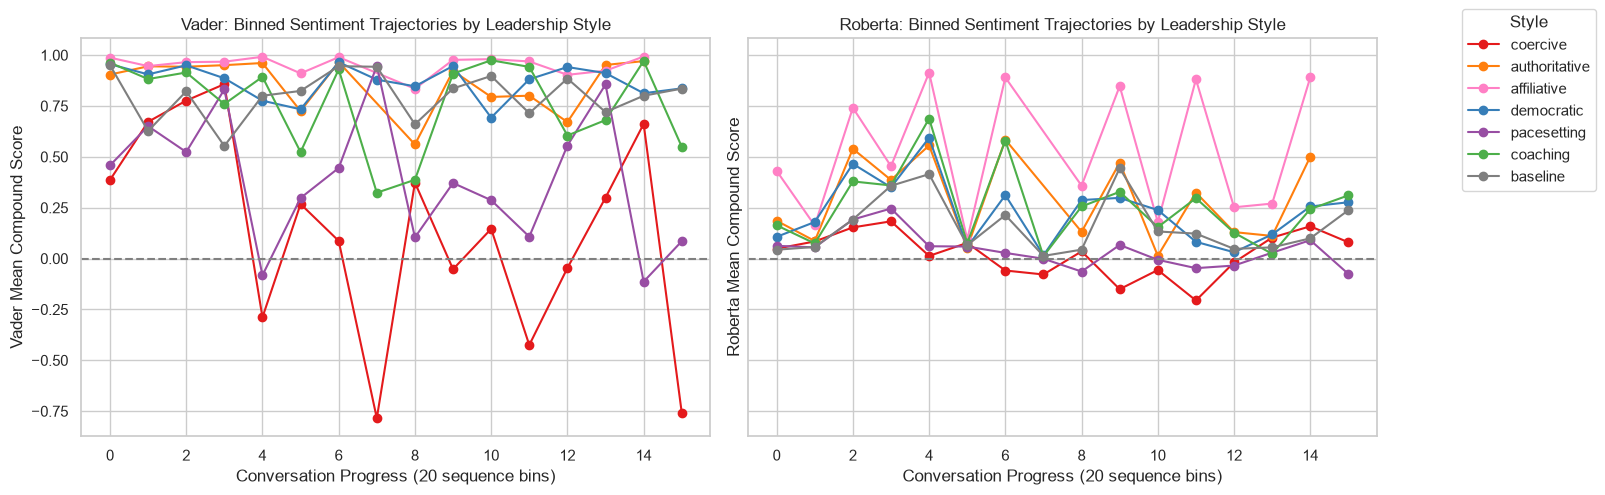

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, analyzer in enumerate(ANALYZERS):
    df_msg, df_run = SENTIMENT[analyzer]
    df_msg = df_msg.copy()
    df_msg['seq_bin'] = pd.qcut(df_msg['seq'], 20, duplicates='drop', labels=False)
    traj = df_msg.groupby(['style', 'seq_bin'], observed=True)['compound'].mean().reset_index()

    for style in STYLE_ORDER:
        style_traj = traj[traj['style'] == style].sort_values('seq_bin')
        if not style_traj.empty:
            axes[i].plot(
                style_traj['seq_bin'], style_traj['compound'],
                marker='o', label=style, color=STYLE_COLORS[style]
            )
    axes[i].axhline(0, color='gray', linestyle='--')
    axes[i].set_title(f'{analyzer.title()}: Binned Sentiment Trajectories by Leadership Style')
    axes[i].set_xlabel('Conversation Progress (20 sequence bins)')
    axes[i].set_ylabel(f'{analyzer.title()} Mean Compound Score')

# Shared legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Style', loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
save_fig('03_sentiment_trajectory_binned')
plt.show()


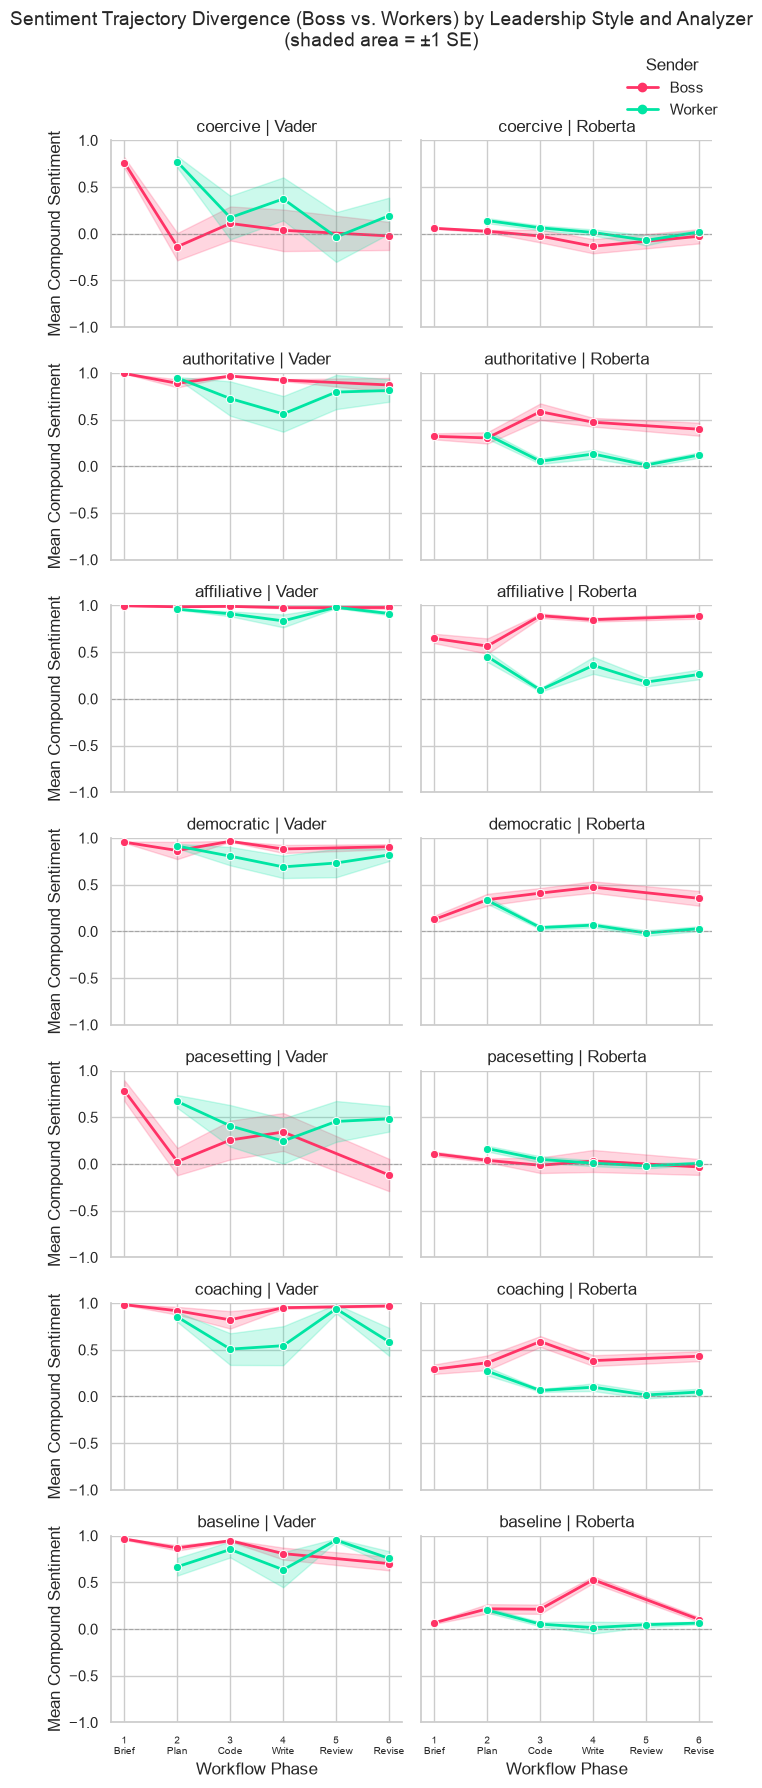

In [8]:
# Faceted Boss vs. Worker sentiment trajectory — one 7×2 combined figure (rows = style, cols = analyzer)
df_list = []
for analyzer in ANALYZERS:
    df_msg, df_run = SENTIMENT[analyzer]
    df = (df_msg
          .assign(run=df_msg['run_dir'],
                  role=np.where(df_msg['sender'] == 'Boss', 'Boss', 'Worker'),
                  analyzer=analyzer.title())
          [['run', 'style', 'task', 'phase', 'role', 'compound', 'analyzer']]
          .copy())
    df_list.append(df)
df_sentiment = pd.concat(df_list, ignore_index=True)

g = sns.FacetGrid(
    df_sentiment,
    row='style', row_order=STYLE_ORDER,
    col='analyzer', col_order=['Vader', 'Roberta'],
    sharey=True, sharex=True,
    height=2.5, aspect=1.4
)

g.map_dataframe(
    sns.lineplot, x='phase', y='compound', hue='role',
    hue_order=['Boss', 'Worker'], palette=BOSS_WORKER_COLORS,
    errorbar='se', linewidth=2, marker='o', markersize=6,
    legend=False
)

for ax in g.axes.flat:
    ax.set_xticks([1, 2, 3, 4, 5, 6])
    ax.set_xticklabels(['1\nBrief', '2\nPlan', '3\nCode', '4\nWrite', '5\nReview', '6\nRevise'], fontsize=7)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

g.set(ylim=(-1.0, 1.0), yticks=[-1.0, -0.5, 0.0, 0.5, 1.0])
g.set_titles(col_template='{col_name}', row_template='{row_name}')
g.set_axis_labels('Workflow Phase', 'Mean Compound Sentiment')

# Shared role legend outside the grid
role_legend = [
    Line2D([0], [0], color=BOSS_WORKER_COLORS['Boss'], lw=2, marker='o', markersize=6, label='Boss'),
    Line2D([0], [0], color=BOSS_WORKER_COLORS['Worker'], lw=2, marker='o', markersize=6, label='Worker')
]
g.fig.legend(handles=role_legend, title='Sender', loc='upper right', bbox_to_anchor=(1.0, 1.0), frameon=False)

g.fig.suptitle(
    'Sentiment Trajectory Divergence (Boss vs. Workers) by Leadership Style and Analyzer\n(shaded area = ±1 SE)',
    fontsize=14, y=1.02
)
g.fig.tight_layout()
save_fig('03_sentiment_trajectory')
plt.show()

## §5 — Emotional Contagion and the Boss–Worker Sentiment Gap

This section compares Boss and worker sentiment and measures how much a worker's tone follows the immediately preceding Boss message. The first two barplots show the mean worker-minus-preceding-boss sentiment delta by leadership style and by responding worker role (Coder, Writer, Reviewer). The third set of barplots displays Boss and worker mean compound scores side by side, alongside the Boss-worker gap; VADER is shown in the upper row of each combined figure and RoBERTa in the lower row.

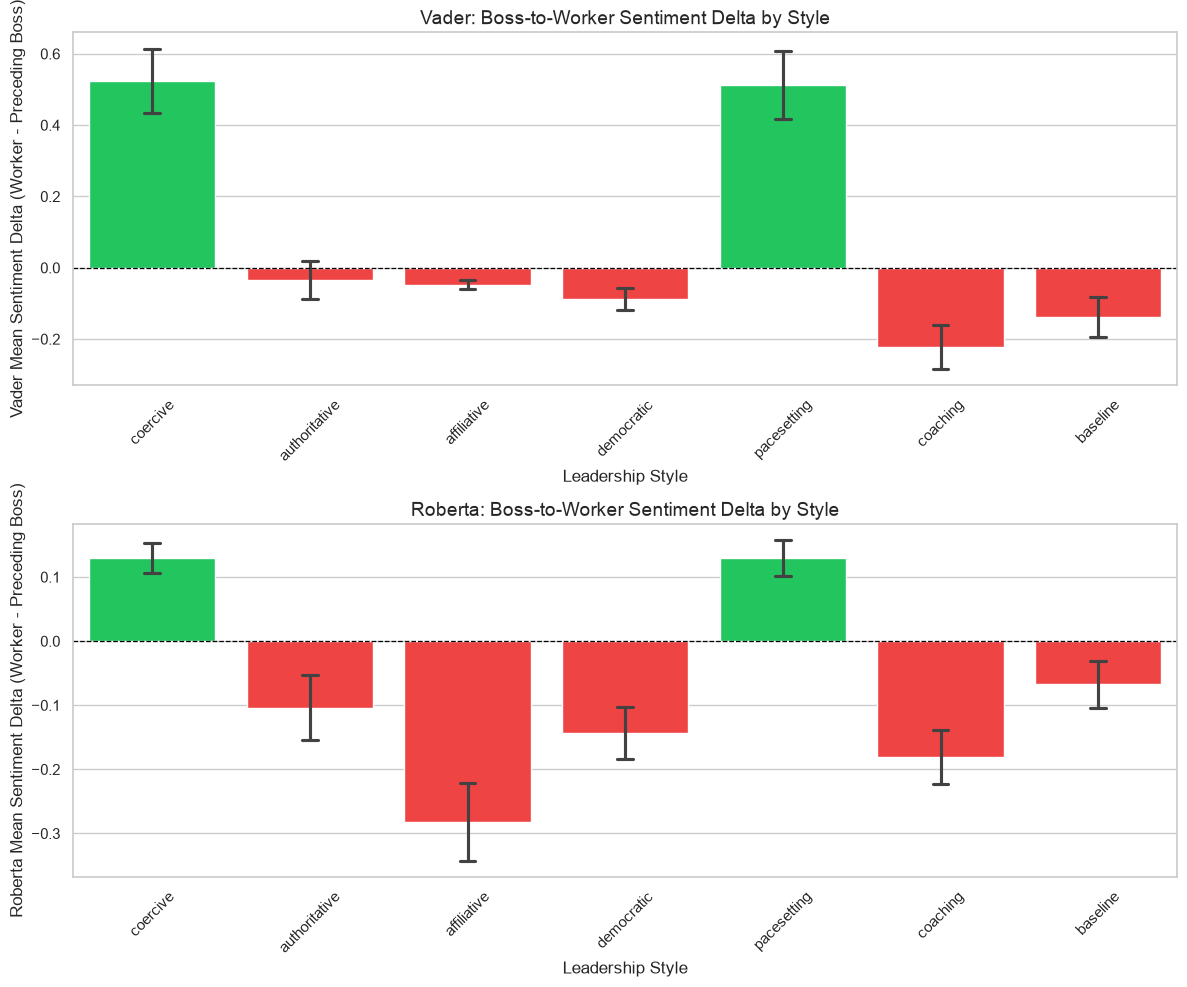

--- VADER ---
Mean sentiment delta by style:
style
coercive         0.52475
authoritative   -0.03507
affiliative     -0.04753
democratic      -0.08863
pacesetting      0.51267
coaching        -0.22247
baseline        -0.13878

--- ROBERTA ---
Mean sentiment delta by style:
style
coercive         0.12981
authoritative   -0.10414
affiliative     -0.28148
democratic      -0.14352
pacesetting      0.12927
coaching        -0.18084
baseline        -0.06749



In [9]:
contagion_pairs = {}  # populated for use in the next sub-section

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for i, analyzer in enumerate(ANALYZERS):
    df_msg, df_run = SENTIMENT[analyzer]

    # Build lagged boss-to-worker pairs
    pair_dfs = []
    for run_dir, grp in df_msg.groupby('run_dir'):
        boss = (grp[grp['sender'] == 'Boss'][['seq', 'compound']]
                .rename(columns={'compound': 'boss_compound'})
                .sort_values('seq'))
        worker = grp[grp['sender'].isin(['Coder', 'Writer', 'Reviewer'])].sort_values('seq')
        if boss.empty or worker.empty:
            continue
        m = pd.merge_asof(worker, boss, on='seq', direction='backward')
        pair_dfs.append(m)
    pairs = pd.concat(pair_dfs, ignore_index=True).dropna(subset=['boss_compound'])
    pairs['delta'] = pairs['compound'] - pairs['boss_compound']
    contagion_pairs[analyzer] = pairs

    delta_mean = pairs.groupby('style', observed=True)['delta'].mean().reindex(STYLE_ORDER)
    delta_colors = ['#22C55E' if d >= 0 else '#EF4444' for d in delta_mean.values]

    sns.barplot(data=pairs, x='style', y='delta', order=STYLE_ORDER,
                errorbar='se', capsize=0.1, ax=axes[i])
    for bar, color in zip(axes[i].patches, delta_colors):
        bar.set_color(color)
        bar.set_edgecolor('white')

    axes[i].axhline(0, color='black', linestyle='--', linewidth=0.9)
    axes[i].set_ylabel(f'{analyzer.title()} Mean Sentiment Delta (Worker - Preceding Boss)')
    axes[i].set_xlabel('Leadership Style')
    axes[i].set_title(f'{analyzer.title()}: Boss-to-Worker Sentiment Delta by Style', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig('03_contagion_boss_to_worker_delta')
plt.show()

for analyzer in ANALYZERS:
    pairs = contagion_pairs[analyzer]
    delta_mean = pairs.groupby('style', observed=True)['delta'].mean().reindex(STYLE_ORDER)
    print(f'--- {analyzer.upper()} ---')
    print('Mean sentiment delta by style:')
    print(delta_mean.round(5).to_string())
    print()


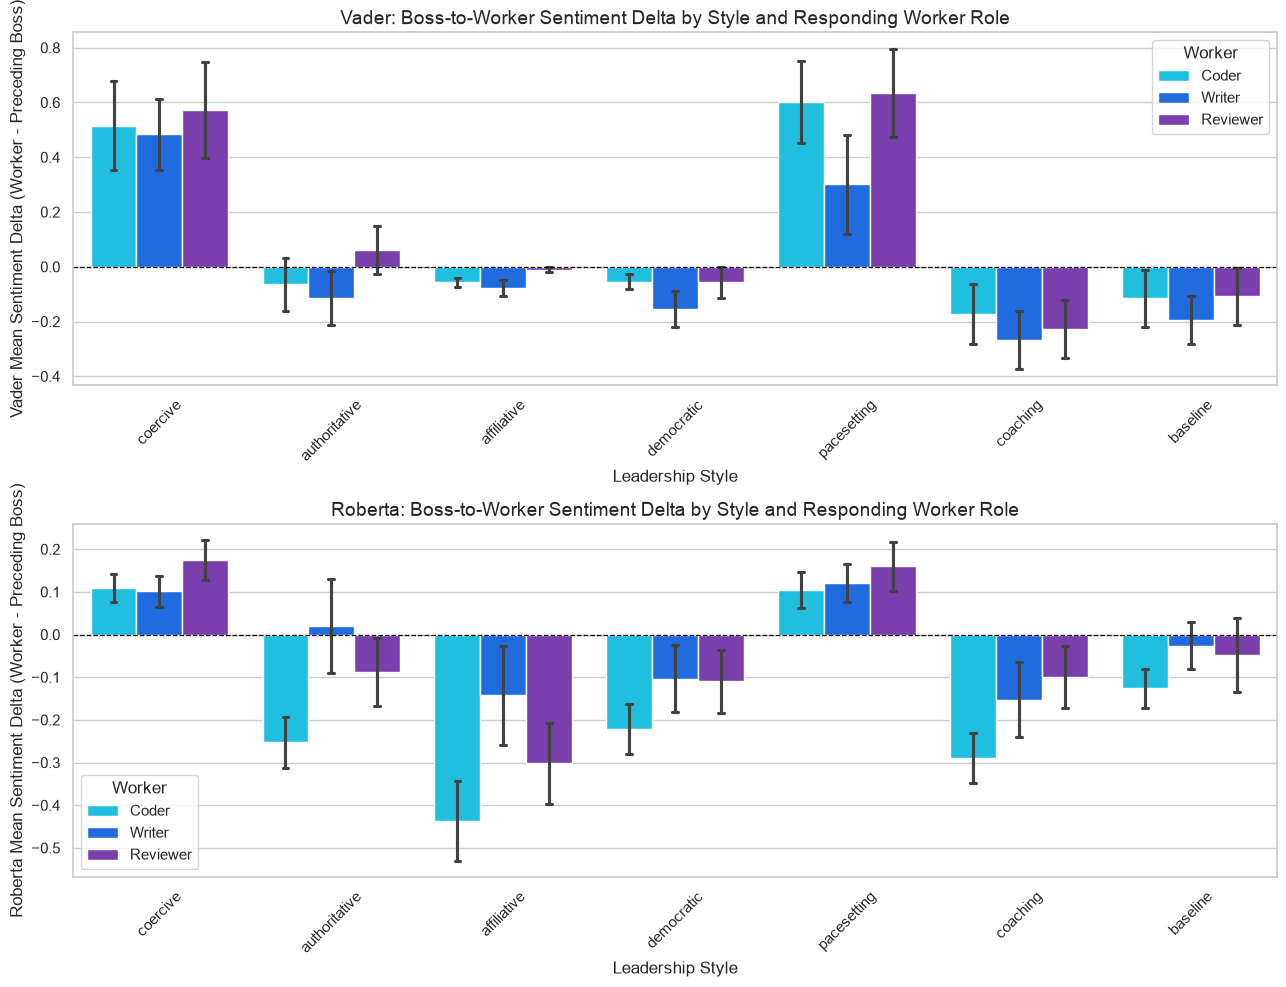

--- VADER ---
Mean sentiment delta by style and worker role:
sender           Coder  Reviewer   Writer
style                                    
coercive       0.51576   0.57261  0.48299
authoritative -0.06480   0.06084 -0.11448
affiliative   -0.05738  -0.01045 -0.07705
democratic    -0.05401  -0.05707 -0.15471
pacesetting    0.60254   0.63574  0.30184
coaching      -0.17376  -0.22715 -0.26809
baseline      -0.11505  -0.10761 -0.19472

--- ROBERTA ---
Mean sentiment delta by style and worker role:
sender           Coder  Reviewer   Writer
style                                    
coercive       0.10924   0.17490  0.10119
authoritative -0.25285  -0.08773  0.01991
affiliative   -0.43632  -0.30127 -0.14259
democratic    -0.22143  -0.10955 -0.10332
pacesetting    0.10344   0.16008  0.12124
coaching      -0.28960  -0.09944 -0.15251
baseline      -0.12608  -0.04788 -0.02595



In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

for i, analyzer in enumerate(ANALYZERS):
    pairs = contagion_pairs[analyzer]

    sns.barplot(
        data=pairs, x='style', y='delta', hue='sender',
        order=STYLE_ORDER, hue_order=['Coder', 'Writer', 'Reviewer'],
        palette=AGENT_COLORS, errorbar='se', capsize=0.1, ax=axes[i]
    )

    axes[i].axhline(0, color='black', linestyle='--', linewidth=0.9)
    axes[i].set_ylabel(f'{analyzer.title()} Mean Sentiment Delta (Worker - Preceding Boss)')
    axes[i].set_xlabel('Leadership Style')
    axes[i].set_title(f'{analyzer.title()}: Boss-to-Worker Sentiment Delta by Style and Responding Worker Role', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Worker', loc='best')

plt.tight_layout()
save_fig('03_contagion_delta_by_worker')
plt.show()

for analyzer in ANALYZERS:
    pairs = contagion_pairs[analyzer]
    print(f'--- {analyzer.upper()} ---')
    print('Mean sentiment delta by style and worker role:')
    print(pairs.groupby(['style', 'sender'], observed=True)['delta'].mean().unstack().round(5).reindex(STYLE_ORDER).to_string())
    print()


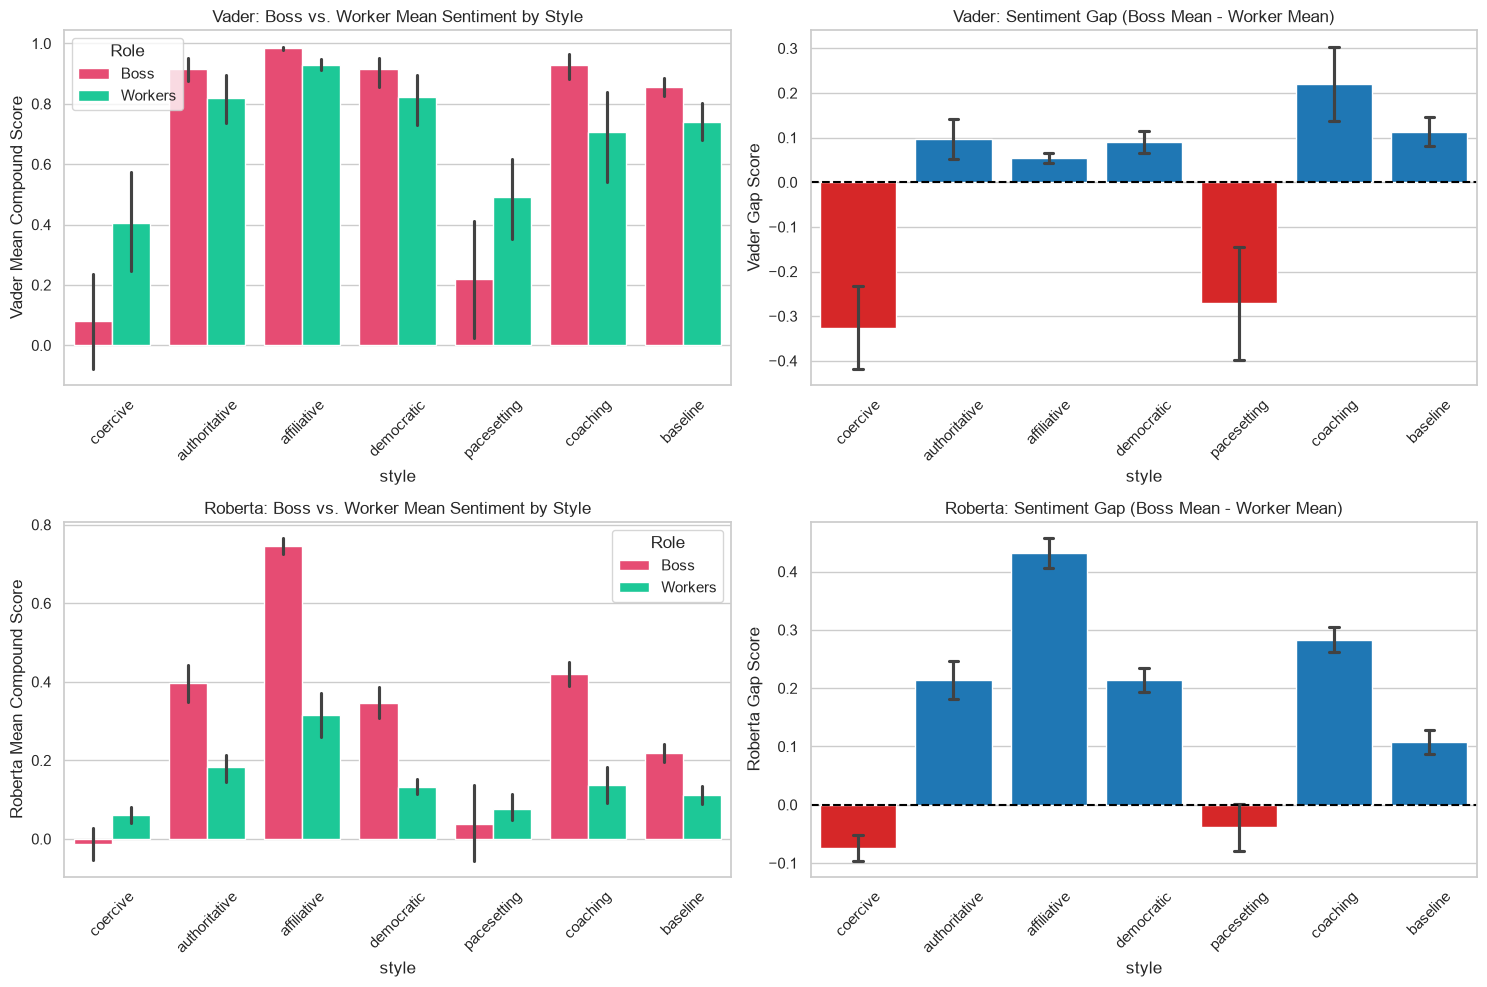

Boss-worker sentiment gap by style (Boss mean - Worker mean):
                VADER  RoBERTa
style                         
coercive      -0.3255  -0.0739
authoritative  0.0974   0.2135
affiliative    0.0541   0.4317
democratic     0.0901   0.2144
pacesetting   -0.2716  -0.0389
coaching       0.2206   0.2832
baseline       0.1135   0.1078


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for i, analyzer in enumerate(ANALYZERS):
    df_msg, df_run = SENTIMENT[analyzer]

    # Left: Boss vs Worker mean
    df_melted = df_run.melt(
        id_vars=['style', 'task'],
        value_vars=['boss_mean_compound', 'worker_mean_compound'],
        var_name='Role', value_name='Compound'
    )
    df_melted['Role'] = df_melted['Role'].map({'boss_mean_compound': 'Boss', 'worker_mean_compound': 'Workers'})

    sns.barplot(data=df_melted, x='style', y='Compound', hue='Role',
                palette=BOSS_WORKER_COLORS, order=STYLE_ORDER, ax=axes[i, 0])
    axes[i, 0].set_title(f'{analyzer.title()}: Boss vs. Worker Mean Sentiment by Style')
    axes[i, 0].set_ylabel(f'{analyzer.title()} Mean Compound Score')
    axes[i, 0].tick_params(axis='x', rotation=45)

    # Right: Boss - Worker gap
    gap_summary = df_run.groupby('style')['boss_worker_gap'].mean().reindex(STYLE_ORDER)
    gap_colors = ['#1f77b4' if g >= 0 else '#d62728' for g in gap_summary.values]

    sns.barplot(data=df_run, x='style', y='boss_worker_gap',
                order=STYLE_ORDER, errorbar='se', capsize=0.1, ax=axes[i, 1])

    for j, bar in enumerate(axes[i, 1].patches):
        bar.set_color(gap_colors[j])
        bar.set_edgecolor('white')

    axes[i, 1].axhline(0, color='black', linestyle='--')
    axes[i, 1].set_title(f'{analyzer.title()}: Sentiment Gap (Boss Mean - Worker Mean)')
    axes[i, 1].set_ylabel(f'{analyzer.title()} Gap Score')
    axes[i, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig('03_boss_worker_sentiment_gap')
plt.show()

# Gap summary for both, side by side
vader_gap = SENTIMENT['vader'][1].groupby('style')['boss_worker_gap'].mean().reindex(STYLE_ORDER).round(4)
roberta_gap = SENTIMENT['roberta'][1].groupby('style')['boss_worker_gap'].mean().reindex(STYLE_ORDER).round(4)
gap_table = pd.concat([vader_gap, roberta_gap], axis=1, keys=['VADER', 'RoBERTa'])
print('Boss-worker sentiment gap by style (Boss mean - Worker mean):')
print(gap_table.to_string())


### VADER conclusion

The style effect on VADER communication tone is still highly significant when every Boss message is removed, and it holds for each worker role separately. Since the worker prompts are identical across all conditions, the tone difference must have been transmitted through the interaction itself. The sentiment finding is therefore emotional contagion, not a lexical artefact of the Boss prompt. (The Boss-only spread is larger, as expected, because the Boss is where the manipulation is applied.)

### RoBERTa conclusion

The style effect on RoBERTa communication tone is still highly significant when every Boss message is removed, and it holds for each worker role separately. Since the worker prompts are identical across all conditions, the tone difference must have been transmitted through the interaction itself. The sentiment finding is therefore emotional contagion, not a lexical artefact of the Boss prompt. (The Boss-only spread is larger, as expected, because the Boss is where the manipulation is applied.)

## §6 — Per-Agent Sentiment Breakdown

A side-by-side boxplot shows the message-level compound distribution for each agent role (Boss, Coder, Writer, Reviewer) across the seven leadership styles, with VADER on the left and RoBERTa on the right. The x-axis is leadership style, the y-axis is the compound score, and each role is colored from the shared agent palette. The shared legend outside the right panel identifies each agent role.

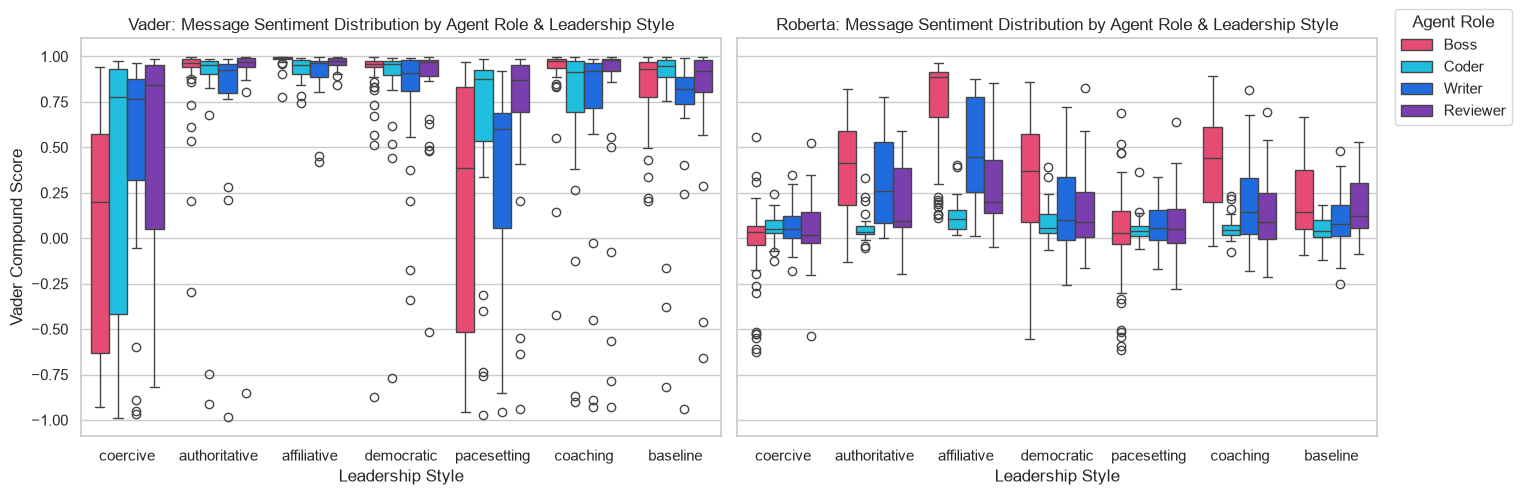

--- VADER ---
Mean (and std) Vader compound score by style and sender:
                 mean                              std                         
sender           Boss   Coder Reviewer  Writer    Boss   Coder Reviewer  Writer
style                                                                          
coercive       0.0882  0.2918   0.4594  0.4652  0.6518  0.7726   0.6795  0.6274
authoritative  0.9159  0.7775   0.8928  0.7725  0.1918  0.5126   0.3508  0.4236
affiliative    0.9844  0.9278   0.9620  0.9005  0.0296  0.0685   0.0388  0.1479
democratic     0.9124  0.8416   0.8505  0.7789  0.2227  0.3395   0.2995  0.3381
pacesetting    0.1901  0.5369   0.6537  0.3297  0.6881  0.6289   0.5203  0.6000
coaching       0.9238  0.6937   0.7263  0.6819  0.1957  0.5136   0.5614  0.5509
baseline       0.8559  0.7641   0.7516  0.7230  0.1792  0.4841   0.4464  0.4029

--- ROBERTA ---
Mean (and std) Roberta compound score by style and sender:
                 mean                              st

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, analyzer in enumerate(ANALYZERS):
    df_msg, df_run = SENTIMENT[analyzer]
    sns.boxplot(
        data=df_msg[df_msg['sender'].isin(['Boss', 'Coder', 'Writer', 'Reviewer'])],
        x='style', y='compound', hue='sender',
        palette=AGENT_COLORS, order=STYLE_ORDER, ax=axes[i]
    )
    axes[i].set_title(f'{analyzer.title()}: Message Sentiment Distribution by Agent Role & Leadership Style')
    axes[i].set_ylabel(f'{analyzer.title()} Compound Score')
    axes[i].set_xlabel('Leadership Style')
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

# Shared legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Agent Role', loc='upper right', bbox_to_anchor=(1.09, 1))

plt.tight_layout()
save_fig('03_sentiment_distribution_by_agent')
plt.show()

for analyzer in ANALYZERS:
    df_msg, df_run = SENTIMENT[analyzer]
    per_agent = df_msg.groupby(['style', 'sender'])['compound'].agg(['mean', 'std']).round(4).unstack()
    print(f'--- {analyzer.upper()} ---')
    print(f'Mean (and std) {analyzer.title()} compound score by style and sender:')
    print(per_agent.to_string())
    print()


## §7 — Phase-Level Sentiment vs. Final Survey Satisfaction

A side-by-side line chart overlays the mean compound sentiment across the six workflow phases with the rescaled final survey satisfaction score for each leadership style, with VADER on the left and RoBERTa on the right. The x-axis shows all seven stages (1 Brief, 2 Plan, 3 Code, 4 Write, 5 Review, 6 Revise, and 7 Survey), and the y-axis is a common score from -1.05 to +1.05. Each leadership style is a colored line with error bands, and the shared legend sits outside the lower-left of the figure.

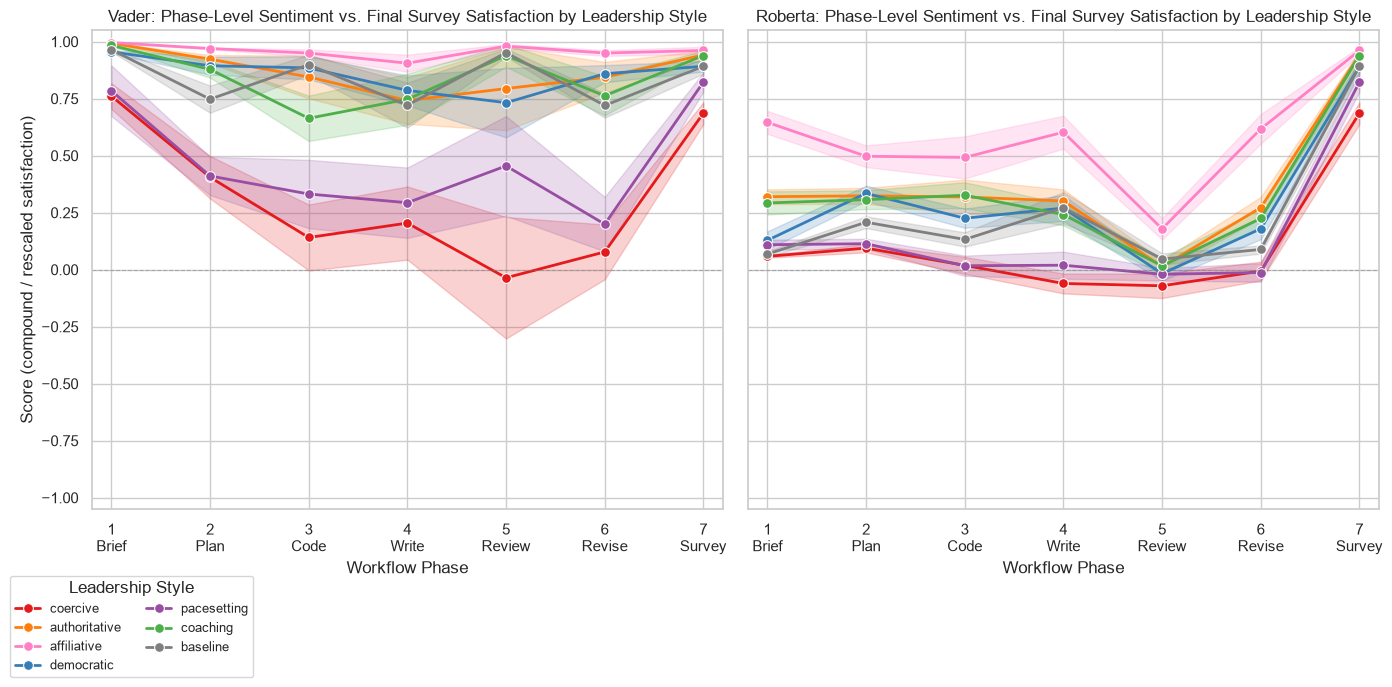

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, analyzer in enumerate(ANALYZERS):
    df_msg, df_run = SENTIMENT[analyzer]

    df_phase_sent = (df_msg
                     .dropna(subset=['phase'])
                     .assign(run=df_msg['run_dir'],
                             phase=lambda d: d['phase'].astype(int),
                             score=lambda d: d['compound'])
                     [['style', 'run', 'phase', 'score']]
                     .copy())

    sat_rows = []
    for d in run_dirs:
        folder = os.path.basename(d)
        parts = folder.split('_')
        surv_file = os.path.join(d, 'survey_results.json')
        if os.path.exists(surv_file):
            with open(surv_file, 'r', encoding='utf-8') as f:
                surv = json.load(f)
            sat_rows.append({
                'style': parts[0],
                'run': folder,
                'phase': 7,
                'score': (surv.get('team_mean', 3.0) - 3.0) / 2.0,
            })

    df_final_sat = pd.DataFrame(sat_rows)
    df_combined = pd.concat([df_phase_sent, df_final_sat], ignore_index=True)
    df_combined['style'] = pd.Categorical(df_combined['style'], categories=STYLE_ORDER, ordered=True)

    sns.lineplot(
        data=df_combined, x='phase', y='score', hue='style',
        hue_order=STYLE_ORDER, palette=STYLE_COLORS,
        estimator='mean', errorbar='se', err_style='band',
        linewidth=2, marker='o', markersize=7, ax=axes[i]
    )

    axes[i].set_xlim(0.8, 7.2)
    axes[i].set_ylim(-1.05, 1.05)
    axes[i].set_xticks([1, 2, 3, 4, 5, 6, 7])
    axes[i].set_xticklabels([
        '1\nBrief', '2\nPlan', '3\nCode', '4\nWrite',
        '5\nReview', '6\nRevise', '7\nSurvey'
    ], rotation=0, ha='center')
    axes[i].axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[i].set_xlabel('Workflow Phase')
    axes[i].set_ylabel('Score (compound / rescaled satisfaction)')
    axes[i].set_title(f'{analyzer.title()}: Phase-Level Sentiment vs. Final Survey Satisfaction by Leadership Style', fontsize=12)
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

# Shared legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Leadership Style', loc='lower left', ncol=2, fontsize=9,
           bbox_to_anchor=(0.0, -0.15))

plt.tight_layout()
save_fig('03_phase_sentiment_vs_survey')
plt.show()


## §8 — Sentiment Component Breakdown

Two stacked barplots show the mean positive, neutral, and negative sentiment probability mass per leadership style, with VADER in the upper panel and RoBERTa in the lower panel. The three components sum to 1.0, so each bar is a complete distribution. Positive is green, neutral is gray, and negative is red; the shared legend outside the top-right identifies each component.

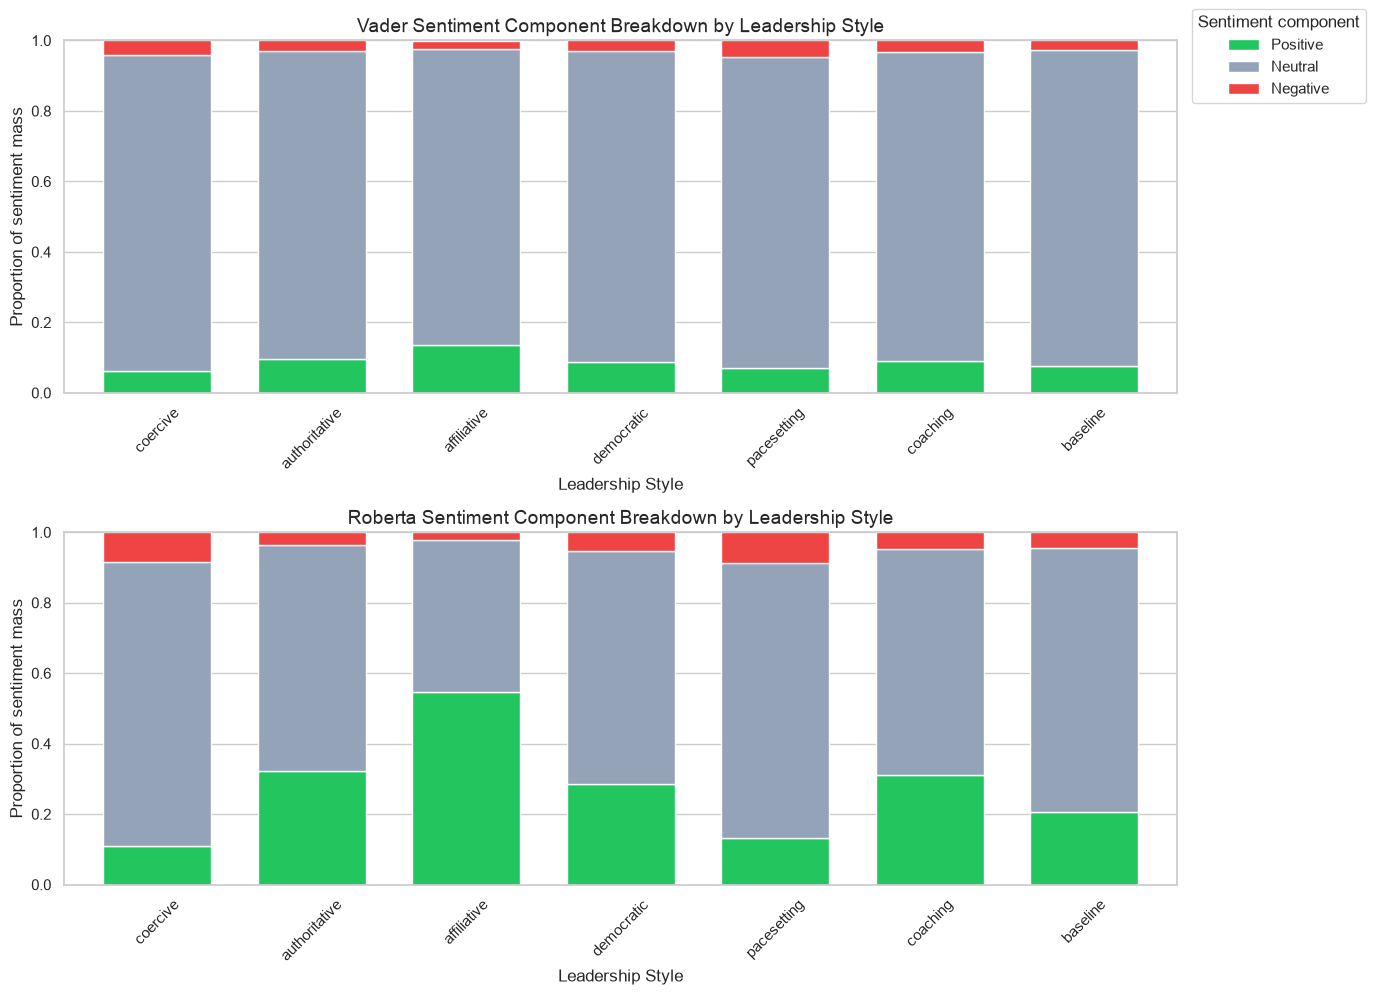

--- VADER ---
Mean Vader component mass by style:
               Positive  Neutral  Negative
style                                     
coercive         0.0619   0.8962    0.0419
authoritative    0.0950   0.8757    0.0294
affiliative      0.1353   0.8411    0.0235
democratic       0.0877   0.8832    0.0291
pacesetting      0.0692   0.8844    0.0463
coaching         0.0901   0.8772    0.0327
baseline         0.0764   0.8959    0.0277

--- ROBERTA ---
Mean Roberta component mass by style:
               Positive  Neutral  Negative
style                                     
coercive         0.1090   0.8071    0.0839
authoritative    0.3225   0.6411    0.0363
affiliative      0.5460   0.4320    0.0221
democratic       0.2849   0.6621    0.0531
pacesetting      0.1332   0.7806    0.0862
coaching         0.3118   0.6395    0.0487
baseline         0.2065   0.7502    0.0433



In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for i, analyzer in enumerate(ANALYZERS):
    df_msg, df_run = SENTIMENT[analyzer]
    comp = (df_msg
            .groupby('style', observed=True)[['positive', 'neutral', 'negative']]
            .mean()
            .rename(columns={'positive': 'Positive', 'neutral': 'Neutral', 'negative': 'Negative'})
            .reindex(STYLE_ORDER))

    comp[['Positive', 'Neutral', 'Negative']].plot(
        kind='bar', stacked=True, color=['#22C55E', '#94A3B8', '#EF4444'],
        edgecolor='white', width=0.7, ax=axes[i]
    )

    axes[i].set_ylim(0, 1.0)
    axes[i].set_ylabel('Proportion of sentiment mass')
    axes[i].set_xlabel('Leadership Style')
    axes[i].set_title(f'{analyzer.title()} Sentiment Component Breakdown by Leadership Style', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()

# Shared legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Sentiment component', loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
save_fig('03_sentiment_components')
plt.show()

for analyzer in ANALYZERS:
    df_msg, df_run = SENTIMENT[analyzer]
    comp = (df_msg
            .groupby('style', observed=True)[['positive', 'neutral', 'negative']]
            .mean()
            .rename(columns={'positive': 'Positive', 'neutral': 'Neutral', 'negative': 'Negative'})
            .reindex(STYLE_ORDER))
    print(f'--- {analyzer.upper()} ---')
    print(f'Mean {analyzer.title()} component mass by style:')
    print(comp.round(4).to_string())
    print()


## §9 — Non-Parametric Statistical Testing

This section tests whether leadership styles differ in overall run-mean compound and in the Boss-worker sentiment gap. A Kruskal-Wallis test compares the seven styles for each metric and analyzer; when the omnibus p-value is below 0.05, pairwise Mann-Whitney U tests compare the baseline to every other style. P-values are reported with and without Bonferroni correction (α = 0.05/6 ≈ 0.0083), and effect sizes are reported as r = |z|/√N.

In [15]:
metrics = {
    'Overall Run Mean Compound': 'run_mean_compound',
    'Boss-Worker Sentiment Gap': 'boss_worker_gap'
}

for analyzer in ANALYZERS:
    df_msg, df_run = SENTIMENT[analyzer]

    stats_sent = []
    pairwise_rows = []
    comparisons = len(STYLE_ORDER) - 1
    alpha_bonf = 0.05 / comparisons

    for name, col in metrics.items():
        groups = [g[col].dropna().values for _, g in df_run.groupby('style')]
        H, p = stats.kruskal(*groups)
        stats_sent.append({
            'Metric': name,
            'H-Statistic': round(H, 3),
            'p-value': round(p, 4),
            'Significant (p < .05)': 'Yes' if p < 0.05 else 'No'
        })

        if p < 0.05:
            baseline_vals = df_run[df_run['style'] == 'baseline'][col].dropna().values
            for style in STYLE_ORDER:
                if style == 'baseline':
                    continue
                style_vals = df_run[df_run['style'] == style][col].dropna().values
                if len(style_vals) == 0 or len(baseline_vals) == 0:
                    continue
                U, p2 = stats.mannwhitneyu(baseline_vals, style_vals, alternative='two-sided')
                n1, n2 = len(baseline_vals), len(style_vals)
                mean_U = n1 * n2 / 2
                sd_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
                z = (U - mean_U) / sd_U
                r = abs(z) / np.sqrt(n1 + n2)
                pairwise_rows.append({
                    'Metric': name,
                    'Style': style,
                    'baseline_mean': round(np.mean(baseline_vals), 4),
                    'style_mean': round(np.mean(style_vals), 4),
                    'U-Statistic': round(U, 1),
                    'p-value': round(p2, 4),
                    'p < 0.05': 'Yes' if p2 < 0.05 else 'No',
                    'p < Bonferroni': 'Yes' if p2 < alpha_bonf else 'No',
                    'Effect r': round(r, 3)
                })

    print('=' * 65)
    print(f'     KRUSKAL-WALLIS STATISTICAL TESTS FOR {analyzer.upper()} SENTIMENT')
    print('=' * 65)
    print(pd.DataFrame(stats_sent).to_string(index=False))

    if pairwise_rows:
        print('\n' + '=' * 65)
        print('     PAIRWISE MANN-WHITNEY U: baseline vs. each style')
        print(f'     Bonferroni-corrected threshold: {alpha_bonf:.4f}')
        print('=' * 65)
        df_pair = pd.DataFrame(pairwise_rows)
        print(df_pair[df_pair['p < 0.05'] == 'Yes'].to_string(index=False))
    print()


     KRUSKAL-WALLIS STATISTICAL TESTS FOR VADER SENTIMENT
                   Metric  H-Statistic  p-value Significant (p < .05)
Overall Run Mean Compound       51.198   0.0000                   Yes
Boss-Worker Sentiment Gap       19.859   0.0029                   Yes

     PAIRWISE MANN-WHITNEY U: baseline vs. each style
     Bonferroni-corrected threshold: 0.0083
                   Metric         Style  baseline_mean  style_mean  U-Statistic  p-value p < 0.05 p < Bonferroni  Effect r
Overall Run Mean Compound      coercive         0.7977      0.2530        100.0   0.0002      Yes            Yes     0.845
Overall Run Mean Compound authoritative         0.7977      0.8653         23.0   0.0452      Yes             No     0.456
Overall Run Mean Compound   affiliative         0.7977      0.9563          1.0   0.0002      Yes            Yes     0.828
Overall Run Mean Compound    democratic         0.7977      0.8650         20.0   0.0257      Yes             No     0.507
Overall Run Mean C

## §10 — Interpretation and Caveats

This section reviews the main findings and the main limitations of each analyzer. The VADER caveat explains that formal agent messages are scored as strongly positive, so absolute magnitudes should be interpreted with caution. The RoBERTa caveat describes the 512-token chunking approach and the tweet-based fine-tuning, motivating a focus on relative patterns and magnitudes rather than on p-values alone.

### VADER caveat

The results above show clear stylist differences in communication tone, but the absolute magnitudes are best interpreted with care because VADER tends to score formal agent messages as strongly positive. The clearest results are the relative differences across leadership styles and roles.

### RoBERTa caveat

Unlike lexicon-based VADER, the RoBERTa model reads sentence structure and context rather than counting keywords, which spreads the scores out far more across conditions. Agent messages are longer than the model's 512-token window, so each message is split into consecutive 510-token chunks, every chunk is scored, and the probabilities are averaged weighted by chunk length. The full message therefore contributes to its score. One limitation remains: the model was fine-tuned on tweets rather than on formal task-oriented messages. Because of these limitations, the safest interpretation uses relative patterns and magnitudes, rather than relying solely on p-values.